# **Getting Started**

*Change runtime type to GPU

## **1. Installation**

### **1.1 Clone the repo**

In [1]:
!git clone https://github.com/separk-1/proj_OBYS.git

Cloning into 'proj_OBYS'...
remote: Enumerating objects: 1171, done.
remote: Counting objects: 100% (248/248), done.
remote: Compressing objects: 100% (144/144), done.
remote: Total 1171 (delta 121), reused 201 (delta 95), pack-reused 923
Receiving objects: 100% (1171/1171), 96.57 MiB | 19.21 MiB/s, done.
Resolving deltas: 100% (490/490), done.


###**1.2 install packages**

In [2]:
%cd proj_OBYS 
!pip install -r requirements.txt

/content/proj_OBYS
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 5.6 MB 5.3 MB/s 
     |████████████████████████████████| 256 kB 45.7 MB/s 
     |████████████████████████████████| 596 kB 39.8 MB/s 
     |████████████████████████████████| 13.5 MB 32.7 MB/s 
     |████████████████████████████████| 23.2 MB 1.5 MB/s 
     |████████████████████████████████| 781 kB 45.8 MB/s 
     \ 665.5 MB 75.6 MB/s
     |████████████████████████████████| 831.4 MB 2.8 kB/s 
     |████████████████████████████████| 22.1 MB 1.4 MB/s 
     |████████████████████████████████| 76 kB 4.7 MB/s 
     |████████████████████████████████| 463 kB 47.6 MB/s 
     |████████████████████████████████| 1.3 MB 39.6 MB/s 
  Attempting uninstall: tensorboard-plugin-wit
    Found existing installation: tensorboard-plugin-wit 1.8.1
    Uninstalling tensorboard-plugin-wit-1.8.1:
      Successfully uninstalled tensorboard-plugin-wit-1.8.1
  A

In [3]:
import yaml
import os

### **2. Process**
#### Yaml file and Execution file
* Since the file path or variables are defined in the yaml file, you need to set the variables when you use the system.
* You can choose the mode for each system through execution bin file.
<p align="center"><img src="https://user-images.githubusercontent.com/78338116/169981538-20e70d37-3658-4285-8fb9-2ff38951d978.png"></p>

## **Usage**

###**0. Dataset**

In [4]:
os.mkdir('./dataset')
%cd dataset 
!gdown https://drive.google.com/uc?id=1P2s1VRzTDoAguTiTN3do8appC2LXgC2H
!unzip -qq "dataset.zip"

if os.path.exists("dataset.zip"):
    os.remove("dataset.zip")
%cd ..

/content/proj_OBYS/dataset
Downloading...
From: https://drive.google.com/uc?id=1P2s1VRzTDoAguTiTN3do8appC2LXgC2H
To: /content/proj_OBYS/dataset/dataset.zip
100% 1.23G/1.23G [00:08<00:00, 152MB/s]
/content/proj_OBYS


### **1. DataPreprocessing**

<p align="center"><img src="https://user-images.githubusercontent.com/78338116/169981862-a3522550-af7d-41e6-9f83-af72704fb28a.png"></p>

#### **1.1 Mode: Foldering**

> Input file: labeled train/validation dataset  
> Output file: Foldered dataset

1) Set config

*   Double click config/config.yaml
*   Set parameter for running
  -  case_name: folder name  
  -  train_dir: train cycle folders  
  -  val_dir: validation cycle folders


2) create dataset on case_data folder

In [5]:
%cd codes

/content/proj_OBYS/codes


In [6]:
!python Run_DataPreprocessing.py --mode Foldering

**case_sample uploaded**


### **2. Object Detection**

<p align="center"><img src="https://user-images.githubusercontent.com/78338116/169981910-7b09f5c7-c5b0-48ab-a71a-4c0a5371b611.png"></p>

#### **2.1 Mode: Training**
>Input file : Train dataset , Pre-trained model(weights)  
>Setting condition : batch size, epoch  
>Output file : Custom trained model(weights)

In [7]:
!python object_detection.py --mode training

train: weights=/content/proj_OBYS/weights/OD_train_result/result_1121_epoch100_30/weights/best.pt, cfg=, data=/content/proj_OBYS/dataset/case_data/case_sample/case_sample.yaml, hyp=data/hyps/hyp.scratch.yaml, epochs=3, batch_size=4, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, adam=False, sync_bn=False, workers=8, project=./weights/OD_train_result/, entity=None, name=case_sample, exist_ok=False, quad=False, linear_lr=False, label_smoothing=0.0, upload_dataset=False, bbox_interval=-1, save_period=-1, artifact_alias=latest, local_rank=-1, freeze=0
fatal: ambiguous argument 'main..origin/master': unknown revision or path not in the working tree.
Use '--' to separate paths from revisions, like this:
'git <command> [<revision>...] -- [<file>...]'
github: Command 'git rev-list main..origin/master --count' returned non-zero exit status 128.
YOLOv5 🚀 9793b

#### **2.2 Mode: Prediction**
>Input file : Test video, Custom pre-trained model(weights)  
>Setting condition : confidence threshold  
>Output file : prediction result(pkl file)

In [20]:
!python object_detection.py --mode prediction

detect: weights=['../weights/OD_train_result/result_1121_epoch100_30/weights/best.pt'], source=../dataset/test_data/cycle2.mp4, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=../results/OD_predict_result/, name=cycle2, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False
requirements: /content/proj_OBYS/codes/requirements.txt not found, check failed.
YOLOv5 🚀 9793b68 torch 1.9.0+cu102 CUDA:0 (Tesla K80, 11441.1875MB)

Fusing layers... 
Model Summary: 224 layers, 7097062 parameters, 0 gradients
video 1/1 (1/21430) /content/proj_OBYS/codes/../dataset/test_data/cycle2.mp4: 384x640 1 drill_jumbo, Done. (0.027s)
video 1/1 (2/21430) /content/proj_OBYS/codes/../dataset/test_data/cycle2.mp4: 384x640 1 drill_jumbo, Done. (0.026s)
video 1/1 (3/21430) /content/proj_OBYS/codes/.

#### **2.3 Mode: Postprocessing**
>Input file : Prediction result(pkl file)  
>Output file : Revised prediction result(ID and Coordinate csv files)

In [21]:
!python object_detection.py --mode postprocessing

### **3. Activity Recognition**

<p align="center"><img src="https://user-images.githubusercontent.com/78338116/169982167-6671f569-aa8f-44a7-a4c1-dac731f1302b.png"></p>


#### **3.1 Mode: Training**
>Input file : Csv format file for training  
>Setting condition : step size, hidden layer, batch size, epoch  
>Output file : Trained model(weights)

In [22]:
!python activity_recognition.py --mode training

sys:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22) have mixed types.Specify dtype option on import or set low_memory=False.
reduced size of data (52963, 22, 10)
Reshape the segments (52963, 10, 22)
(37074, 10, 22) (15889, 10, 22) (37074, 7) (15889, 7)
Epoch 1/3
1155/1159 [============================>.] - ETA: 0s - loss: 0.9381 - accuracy: 0.7290
Epoch 00001: saving model to ../weights/AR_train_result/cp.ckpt
1159/1159 [==============================] - 21s 14ms/step - loss: 0.9364 - accuracy: 0.7297 - val_loss: 0.3367 - val_accuracy: 0.9517
Epoch 2/3
1157/1159 [============================>.] - ETA: 0s - loss: 0.2454 - accuracy: 0.9661
Epoch 00002: saving model to ../weights/AR_train_result/cp.ckpt
1159/1159 [==============================] - 15s 13ms/step - loss: 0.2455 - accuracy: 0.9660 - val_loss: 0.1087 - val_accuracy: 0.9806
Epoch 3/3
1159/1159 [==============================] - ETA: 0s - loss: 0.1236 - accuracy: 0.9793
Epoch 00003: saving 

#### **3.2 Mode: Predicting**
>Input file : Csv format file, Pre-trained model(weights)  
>Setting condition : step size, hidden layer, batch size, epoch  
>Output file : Csv format file with prediction

In [23]:
!python activity_recognition.py --mode predicting

2022-05-25 10:01:37.059300: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:39] Overriding allow_growth setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
reduced size of data (6970, 22, 10)
Traceback (most recent call last):
  File "activity_recognition.py", line 179, in <module>
    X_test = load_data_without_gt(df, columns, N_TIME_STEPS, num_equipment,step)
  File "activity_recognition.py", line 72, in load_data_without_gt
    reshaped_segments = np.asarray(segments,dtype=np.float32).reshape(-1, N_TIME_STEPS, N_FEATURES)
ValueError: could not convert string to float: 'drill_jumbo_cx'


### **4. Result analysis**

<p align="center"><img src="https://user-images.githubusercontent.com/78338116/169982951-041f05da-8a24-4a8f-a006-3a5e3387c04f.png"></p>


#### **4.1 Mode: Time Table**
>Input file : Activity predicted ID file  
>Setting condition : time interval  
>Output file : Time Table(Activity & Equipment)

In [24]:
%run result_analysis.py --mode time_table

In [25]:
Equipment_timetable

,1,2,3,4,5,6,7,8,9,10,...,248,249,250,251,252,253,254,255,256,257
drill_jumbo,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
gunpowder_carrier,0,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
work platform,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
breaker,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
excavator,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
Activity_timetable

,1,2,3,4,5,6,7,8,9,10,...,248,249,250,251,252,253,254,255,256,257
A,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
B,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
D,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
E,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### **4.2 Mode: Cycle Time**
>Input file : Activity predicted ID file  
>Setting condition : Activity Classes  
>Output file : Activity Cycle Time

In [27]:
%run result_analysis.py --mode activity_cycle_time

In [28]:
activity_cycle_time

,activity,start_time,end_time,gap
0,Drilling&Loading,0,3516,3517
1,nothing,3517,4238,722
2,Scaling,4239,4248,10
3,Mucking,4249,5969,1721
4,Scaling,5970,6000,31
5,Mucking,6001,6756,756
6,Scaling,6757,7622,866
7,nothing,7623,7662,40
8,Scaling,7663,8121,459
9,nothing,8122,8157,36


#### **4.3 Mode: counting dump_truck and payloader**
>Input file : Activity predicted ID and Coordinate file  
>Output file : Number of countings

In [29]:
%run result_analysis.py --mode counting_dumptruck 

Dumptruck Counting : 14


In [30]:
dumptruck_counting

,ID,InTime,OutTime
0,0,0,4325
1,1,4326,4401
2,0,4402,4430
3,1,4431,4523
4,0,4524,4585
5,1,4586,4682
6,0,4683,4740
7,1,4741,4835
8,0,4836,4889
9,1,4890,4990


Payloader Counting : 77


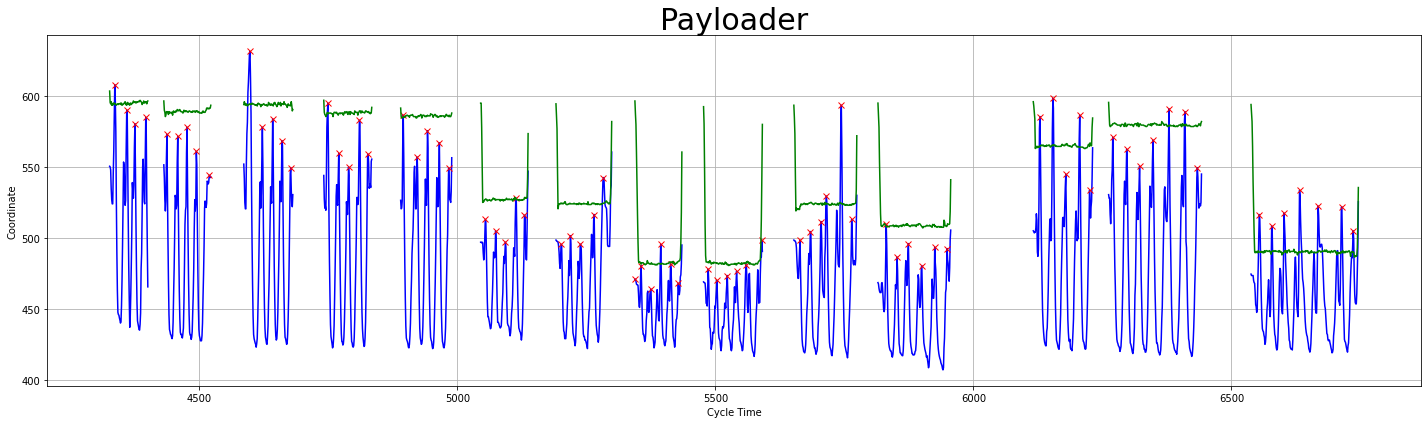

In [31]:
%run result_analysis.py --mode counting_payloader